# Class 20: Monte Carlo Simulation

Ch. 10, section 3: Monte Carlo Simulation
- Importance sampling and statistial mechanics
- The Markov Chain method

Complete the activities as instructed by the professor

#### Import any packages we need below (update as we go):

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt

### Example 10.3: Monte Carlo Simulation of an Ideal Gas

The quantum states of a particle or atom of mass $m$ in a cubic box of length $L$ on each side have three integer quantum numbers $n_x, n_y, n_z = 1...\infty$ and energies given by
$$E(n_x, n_y, n_z) = \frac{\pi^2\hbar^2}{2mL^2} (n_x^2+ n_y^2+ n_z^2) $$
An ideal gas is a gas of $N$ such atoms that do not interact with one another in any way, so that their total energy is just the sum of the energies of the individual particles: 
$$E = \sum_{i=1}^N E(n_x^{(i)}, n_y^{(i)}, n_z^{(i)})$$
where $n_x^{(i)}$ is the value of the quantum number $n_x$ for the $i\text{th}$ atom, and similarly for $n_y^{(i)}$ and $n_z^{(i)}$. In this example, we will perform a Monte Carlo simulation for such an ideal gas and use it to calculate the internal energy of the gas. 

**The move set:** First we need to choose a move set. In this case, we will let the move set be the set of all moves of a single atom to one of the six neighboring states where $n_x, n_y, \text{ or } n_z$ differs by $\pm 1$. On each step of the Monte Carlo simulation we will choose a random particle, choose one of the three quantum numbers $n_x, n_y, \text{ or } n_z$, and choose a random changes, either $+1$ or $-1$, for the quantum number. When we make such a move, just one term in the total energy changes, the term for the atom $i$ that changes state. If, for example, $n_x$ for an atom $i$ increases by 1, then the change will be: 

$$ \Delta E = \frac{\pi^2\hbar^2}{2mL^2} \left[ (n_x+1)^2+ n_y^2+ n_z^2 \right] -\frac{\pi^2\hbar^2}{2mL^2} (n_x^2+ n_y^2+ n_z^2) $$

$$ \qquad = \frac{\pi^2\hbar^2}{2mL^2} \left[ (n_x+1)^2 - n_x^2 \right] =\frac{\pi^2\hbar^2}{2mL^2} (2n_x +1) $$

where we have suppressed the superscript on $n_x^{(i)}$ in the interest of clarity. Similarly, if $n_x$ decreases by 1 we have
$$ \Delta E =\frac{\pi^2\hbar^2}{2mL^2} (-2n_x + 1)$$

**Now:** We will write a program to perform the simulation for $N = 1000$ particles when $k_BT = 10$. For simplicity, we work with units where $m = \hbar = 1$ and set the size of box to be $L=10$. It does not matter greatly what state we start our system in, so let us just start with all particles in the ground state $n_x=n_y=n_z = 1$. Then we can select at random the particle, axis, and sign for the first move, calculate the energy change $\Delta E = E_r-E_s$, and then either accept or reject the move according to the Metropolis probability. Then we simply repeat th whole process for many moves. (Notice that if a particle is in an $n=1$ state and we happen to chose to decrease the value of the quantum number $n$, then the move is always rejected because there is no lower value of $n$.)

Let's now perform the entire calculation, and make a plot of the total energy of the gas as a function of time for 10 million Monte Carlo steps. 

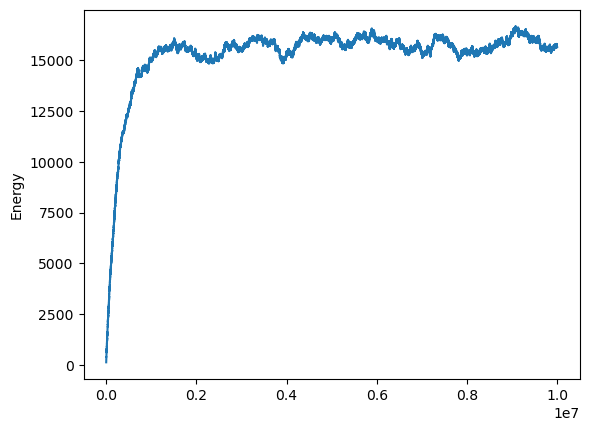

The expectation value is = 15252.606818469458


In [8]:
#Defin constants for the problem

kBT = 10. 
L = 10. #Size of box
N = 1000 #Number of particles
steps = 10000000

# create 2D Array to store quatum numbers
n = np.ones([N,3], int)
# create blank list of Energy values
E_pts = []
#Calculate the starting energy ofthe system -> m = hbar = 1
E = N*3*(np.pi**2)/(2*L**2)

#MCMC loop
for k in range(steps):
    #Choose particle and move using random numbers
    i = random.randrange(N) #Choosing Particle out of 1000
    j = random.randrange(3) # choose quantum number (nx, ny, or nz)
    # choose the move up or down
    if random.random() < 0.5:
        dn = 1
        dE = (2*n[i,j]+1)*(np.pi**2/(2*L**2))
    else:
        dn = -1
        dE = (-2*n[i,j]+1)*(np.pi**2/(2*L**2))

    #THIS STATEMENT IS ONLY FOR THIS PROBLEM
    if n[i,j] > 1 or dn == 1:
        #Apply the metropolis algorithm
        if random.random() < np.exp(-dE/kBT):
            #Accept the move
            n[i,j] += dn
            E += dE

    #append the new energy to the list
    E_pts.append(E)

#Graph the results
plt.plot(E_pts)
plt.ylabel("Energy")
plt.show()

print("The expectation value is =", np.sum(E_pts)/steps)